# **Anime - Data Analysis**

## **Introduction**
---
- This project analyzes an Anime dataset to understand viewer preferences, ratings distribution, and genre popularity.

- The main objective is to find patterns between variables such as rating, number of members, episodes, and genre.

- The analysis helps identify the most popular anime genres and factors influencing anime ratings.

### **Column descriptions for the Anime dataset:**

1. anime_id – Unique identification number assigned to each anime.

2. name – Title of the anime.

3. genre – Genre category of the anime such as Action, Comedy, Drama, or Fantasy.

4. type – Format in which the anime was released (TV, Movie, OVA, ONA, Special, or Music).

5. episodes – Total number of episodes of the anime.

6. rating – Average viewer rating on a scale of 1 to 10.

7. members – Total number of users who added the anime to their watchlist.

In [42]:
# import libraries for data analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [43]:
warnings.filterwarnings("ignore")

In [44]:
from google.colab import drive     # connect google drive with colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
df = pd.read_csv("/content/drive/MyDrive/Data analysis project/anime.csv")    # load dataset of anime

In [46]:
df.head()   # display first 5 records

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [47]:
df.tail()   # display last 5 records

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,NaN,OVA,1,4.15,211
12290,5543,Under World,NaN,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,NaN,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,NaN,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,NaN,Movie,1,5.46,142


### **Data Understanding / Data Process**
---

#### Check the dataset structure, columns, and basic statistics; identify missing values.

In [48]:
df.info()   # display columns information like: count of null values, data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     11409 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [49]:
df.shape    # display rows and columns number

(12294, 7)

In [50]:
df.columns    # display all columns name

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [51]:
df.columns = ['anime id', 'anime name', 'genre', 'type', 'episodes', 'rating', 'members']   # rename column names

In [52]:
df["episodes"] = pd.to_numeric(df["episodes"], errors='coerce')   # convert data type from object to integer

### **Data Cleaning**
---

#### Handle missing data, transform data types, and manage outliers.

In [53]:
(df.isnull().sum() / len(df)) * 100   # check percentage of null value

,0
anime id,0.000000
anime name,0.000000
genre,7.198633
type,0.203351
episodes,2.765577
rating,1.870831
members,0.000000


In [54]:
cleaned_data = df.dropna()    # dropping null values

In [55]:
cleaned_data = cleaned_data.drop(columns=["anime id"])

In [56]:
cleaned_data.isnull().sum() / len(df) * 100

,0
anime name,0.0
genre,0.0
type,0.0
episodes,0.0
rating,0.0
members,0.0


### **Exploratory Data Analysis (EDA)**
---

####Analyze summary statistics, correlations, and identify trends or issues.

In [57]:
cleaned_data.describe()     # statstical table representation

,episodes,rating,members
count,11045.000000,11045.000000,1.104500e+04
mean,13.229153,6.504679,1.964694e+04
std,48.655875,1.036618,5.713133e+04
min,1.000000,1.670000,1.200000e+01
25%,1.000000,5.910000,2.050000e+02
50%,2.000000,6.600000,1.514000e+03
75%,13.000000,7.230000,1.159600e+04
max,1818.000000,10.000000,1.013917e+06


In [58]:
df_corr = cleaned_data.corr(numeric_only= True)   # correlation table

In [59]:
df_corr

,episodes,rating,members
episodes,1.000000,0.085181,0.051472
rating,0.085181,1.000000,0.391958
members,0.051472,0.391958,1.000000


### **Data Visualization with Insights**
---

#### Create charts (e.g., bar, line, heatmap, box plots) to visualize key trends and patterns.

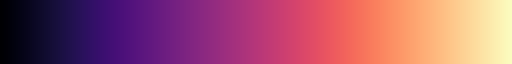

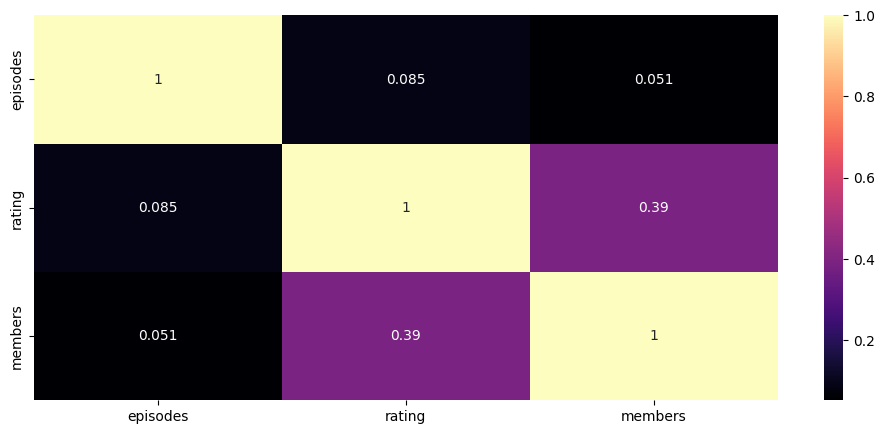

In [77]:
# Heatmap - Heatmap to understand relationship between rating, episodes, and members

plt.figure(figsize = (12, 5))
sns.heatmap(df_corr, annot = True, cmap="magma")      # describe correlation using heatmap

sns.color_palette("magma", as_cmap=True)

**Insights:**
1. There is a moderate positive correlation **(0.39)** between **members and rating**.
2. There is a very weak correlation **(0.088)** between **rating and episodes**.
3. There is almost no correlation **(0.056)** between **members and episodes**.
4. Each variable shows perfect correlation **(1.0)** with itself on the heatmap diagonal.

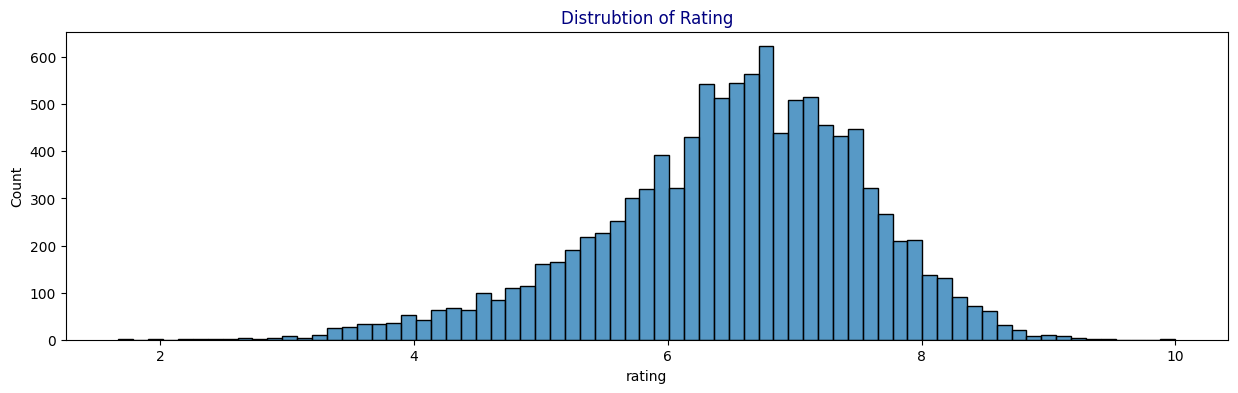

In [76]:
# Histogram chart distrubtion - Visualizing how anime ratings are distributed among viewers

plt.figure(figsize = (15, 4))   # set size of graph (width, height)

sns.histplot(x = cleaned_data["rating"])
plt.title("Distrubtion of Rating", color = "navy")    # set title of graph
plt.show()

**Insights:**
1. Rating value **7** has the highest frequency compared to ratings **2, 4, 6, and 10**.
2. The rating frequency increases from rating **4** and reaches a peak at rating **7**.
3. After rating **7**, the frequency gradually decreases up to rating **10**.

In [62]:
top_gen = df['genre'].value_counts().head(10)

In [63]:
top_gen

,count
genre,
Comedy,523
Music,301
Kids,199
"Comedy, Slice of Life",179
Dementia,137
"Fantasy, Kids",128
Fantasy,114
"Comedy, Kids",112
Drama,107


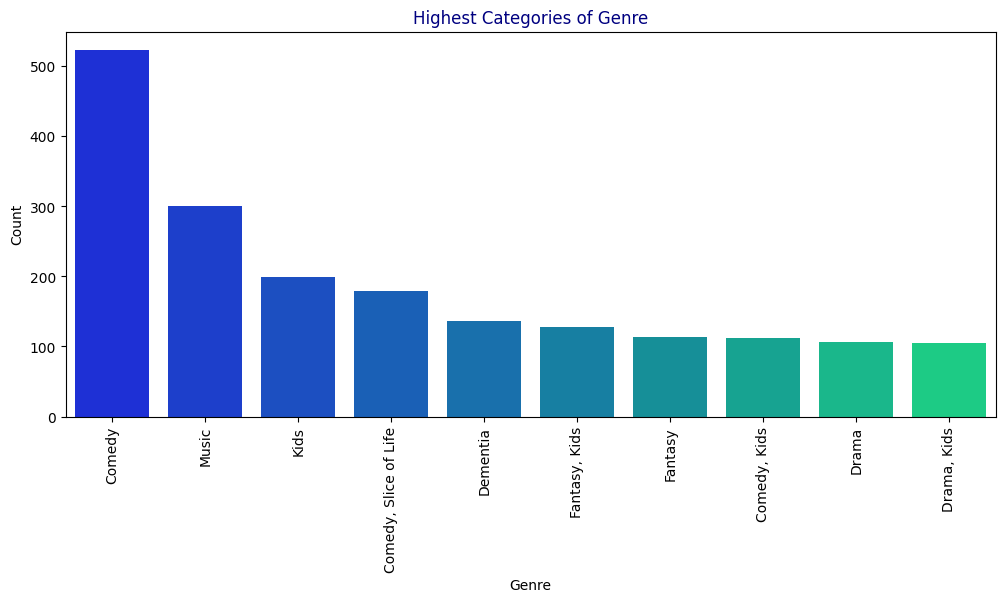

In [64]:
# Bar Plot - Identifying the most popular anime genres based on frequency

plt.figure(figsize = (12, 5))
sns.barplot(x = top_gen.index, y = top_gen.values, palette="winter")

plt.title("Highest Categories of Genre", color="navy")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation = 90)   # rotation of x-axis label

plt.show()

**Insights:**
1. **Comedy** is the most watched genre with a **count of 523**.
2. **Music** is the second most watched genre with a **count of 301**, showing a **gap of 222** compared to Comedy.
3. **Drama** is the least watched genre with a **count of 107**.
4. **Fantasy, Kids, and Drama** genres have similar viewer **counts close to 112**.

In [65]:
data_rating = cleaned_data.groupby("anime name")["rating"].mean().sort_values(ascending = False).head(10)  # average of rating

In [66]:
data_rating

,rating
anime name,
Taka no Tsume 8: Yoshida-kun no X-Files,10.00
Mogura no Motoro,9.50
Kimi no Na wa.,9.37
Kahei no Umi,9.33
Fullmetal Alchemist: Brotherhood,9.26
Gintama°,9.25
Yakusoku: Africa Mizu to Midori,9.25
Steins;Gate,9.17
Gintama&#039;,9.16


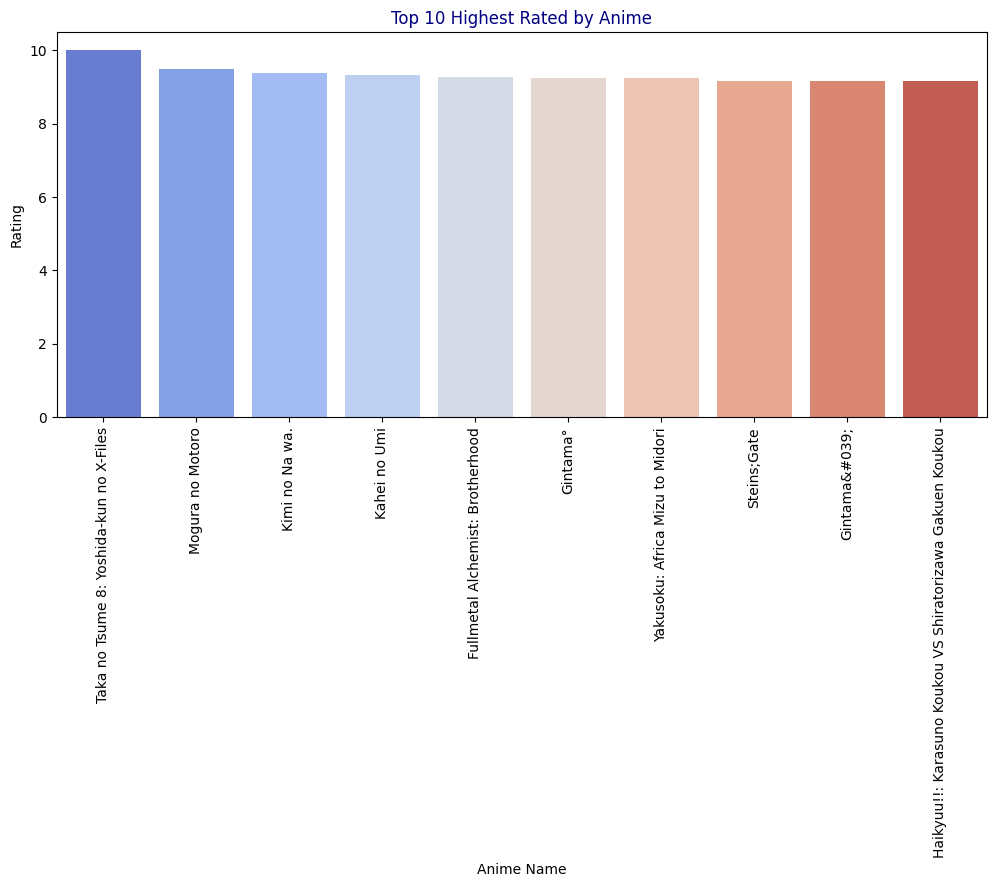

In [67]:
# Bar Plot - Displaying anime with the highest viewer ratings

plt.figure(figsize = (12, 5))
sns.barplot(x = data_rating.index, y = data_rating.values, palette="coolwarm")  # x-axis index of anime name and y-axis values of average rating

plt.title("Top 10 Highest Rated by Anime", color="navy")
plt.xlabel("Anime Name")
plt.ylabel("Rating")

plt.xticks(rotation = 90)

plt.show()

**Insights:**

1. The anime **Taka no Tsume 8: Yoshida-kun no X-Files** has the **highest rating of 10**.

2. **Gintama and Yakusoku: Africa Mizu to Midori** have very similar ratings.

3. **Steins Gate**, **Gintama 039**, and **Haikyuu: Karasuno Koukou** VS **Shiratorizawa Gakuen Koukou** also show closely similar ratings.

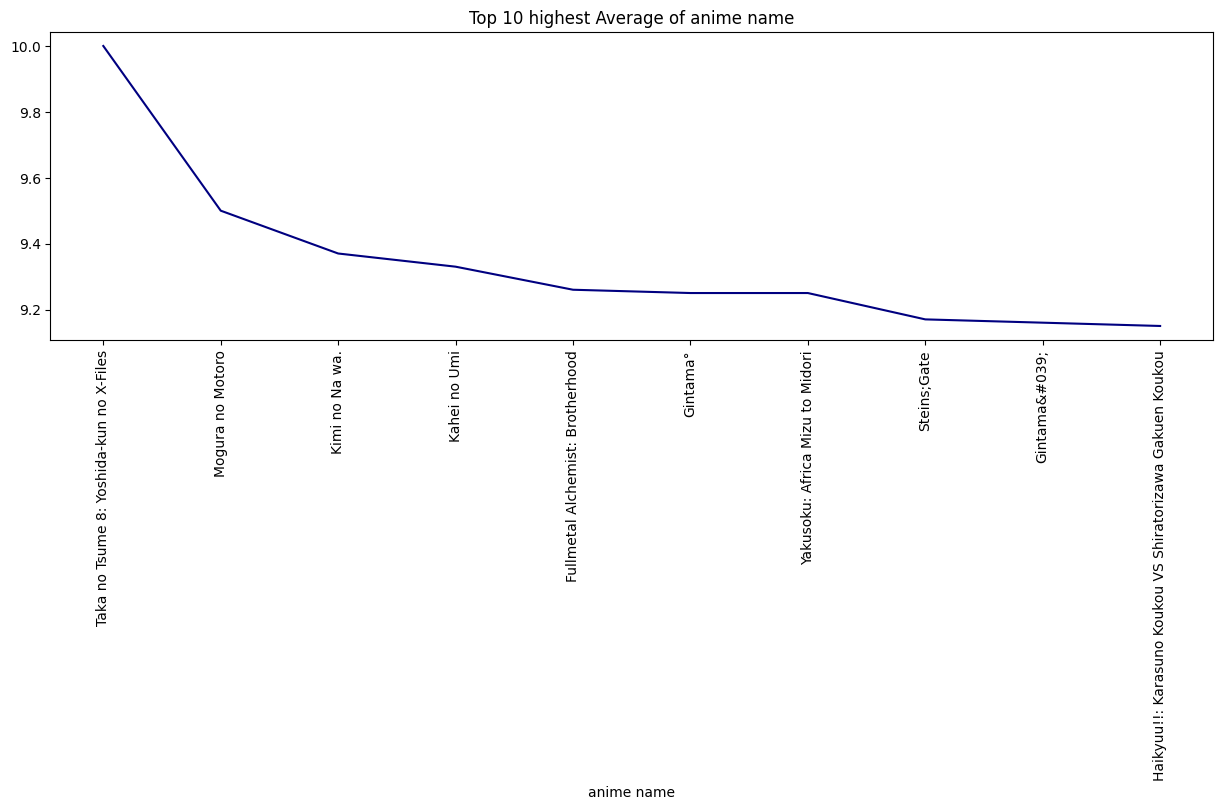

In [68]:
# Line Plot - Showing anime with the highest average viewer ratings

plt.figure(figsize = (15, 4))
ax = sns.lineplot(x = data_rating.index, y = data_rating.values, color = "navy")

plt.title("Top 10 highest Average of anime name")
plt.xticks(rotation = 90)
plt.show()

**Insights:**

1. **Taka no Tsume 8: Yoshida-kun no X-Files** has the highest average rating of **10**.

2. **Haikyuu: Karasuno Koukou VS Shiratorizawa Gakuen Koukou** has the **lowest average rating of 9.15** among the top-rated anime.

3. **Mogura no Motoro** shows a rating decline compared to **Haikyuu…**.

In [69]:
top_episodes = cleaned_data.groupby("anime name")["episodes"].sum().sort_values(ascending=False).head(10)

In [70]:
top_episodes

,episodes
anime name,
Oyako Club,1818.0
Doraemon (1979),1787.0
Kirin Monoshiri Yakata,1565.0
Manga Nippon Mukashibanashi (1976),1471.0
Hoka Hoka Kazoku,1428.0
Kirin Ashita no Calendar,1306.0
Monoshiri Daigaku: Ashita no Calendar,1274.0
Sekai Monoshiri Ryoko,1006.0
Kotowaza House,773.0


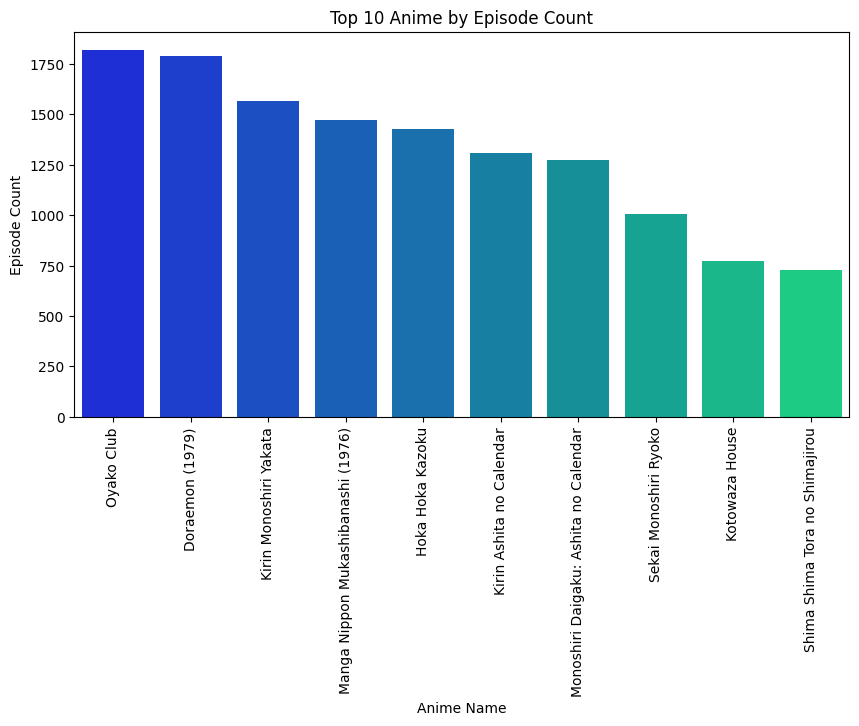

In [71]:
# Bar Plot - Exploring which anime have the highest and lowest episode counts

plt.figure(figsize = (10 ,5))

sns.barplot(x = top_episodes.index, y = top_episodes.values, palette = "winter")

plt.xticks(rotation=90)

plt.xlabel("Anime Name")
plt.ylabel("Episode Count")
plt.title("Top 10 Anime by Episode Count")
plt.show()

**Insights:**

1. **Oyako  Club** has the highest number of episodes with a **count of 1818**.

2. **Shima Shima Tora no Shimajirou** has a lower episode **count of 726**.

3. The popular kids anime **Doraemon (1979)** has the second-highest episode count after **Oyako Club**.

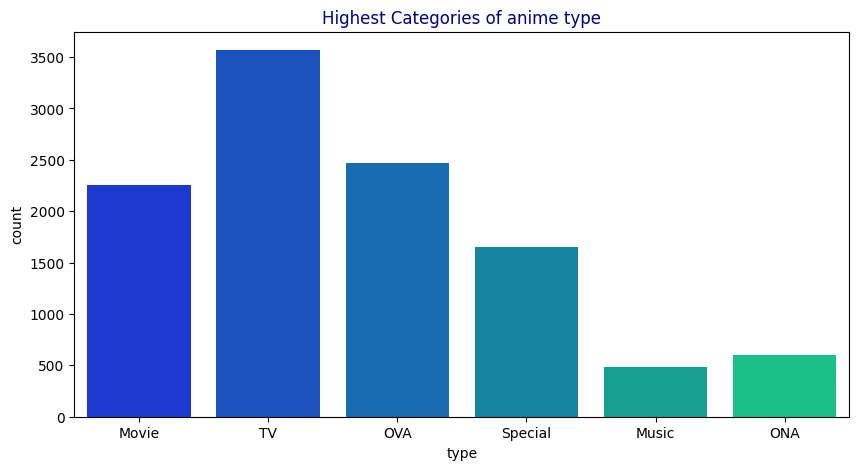

In [72]:
# Count Plot - Comparing number of anime titles across different formats like TV, Movie, OVA

plt.figure(figsize = (10 ,5))

sns.countplot(x = "type", data = cleaned_data, palette = "winter")
plt.title("Highest Categories of anime type", color = "navy")
plt.show()

**Insights:**

1. **TV anime** has the highest number of titles compared to other types.

2. **OVA** is the second most common anime type in the dataset.

3. **Movies** have a moderate count but **fewer titles than TV and OVA**.

4. **Music and ONA** anime have the lowest number of counts.

In [73]:
data_type = cleaned_data.groupby("type")["members"].sum().sort_values(ascending = False).head(10)

In [74]:
data_type

,members
type,
TV,159259721
Movie,23863779
OVA,17722808
Special,12818508
ONA,2695451
Music,640140


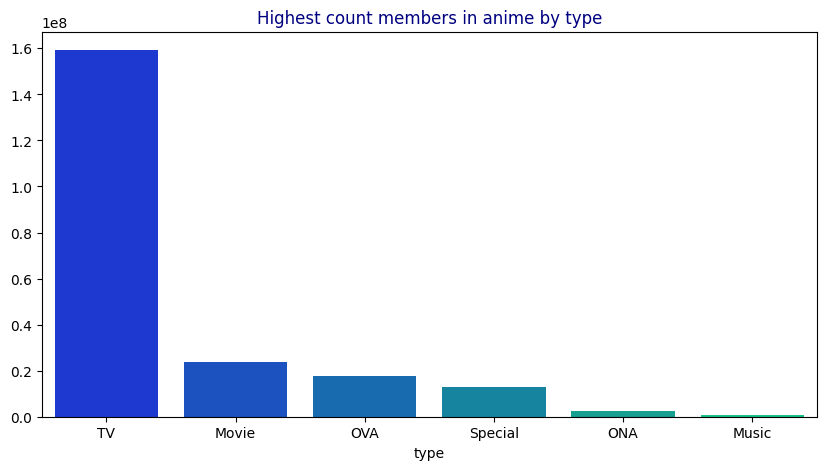

In [79]:
# Bar Plot - howing total viewer popularity (members) across different anime types

plt.figure(figsize = (10 ,5))

sns.barplot(x = data_type.index, y = data_type.values, palette = "winter")
plt.title("Highest count members in anime by type", color = "navy")
plt.show()

**Insights:**

1. **TV anime** has the highest total member popularity among all formats.

2. **Movies** are the second most popular type by member count.

3. **OVA and Special** anime have moderate member popularity.

4. **ONA and Music** anime have the lowest member counts.

## **Conclusion :**

1. TV anime is the most common format, indicating that most anime are released as TV series.

2. TV anime also has the highest popularity, with the largest number of members watching them.

3. OVA and Movie anime are also important, but they are less common than TV anime.

4. Special, ONA, and Music formats have fewer titles and lower viewer popularity.

5. Overall, TV series play the biggest role in the anime industry and attract the most viewers.